In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# set the style of matplotlib
%matplotlib inline
plt.style.use('fivethirtyeight')

# Load the dataset
df = pd.read_csv('/content/parkinsons data.csv')

In [ ]:
df.shape

(195, 24)

In [ ]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.23,41.39,88.33,117.57,148.79,182.77,260.10
MDVP:Fhi(Hz),195.0,197.10,91.49,102.14,134.86,175.83,224.21,592.03
MDVP:Flo(Hz),195.0,116.32,43.52,65.48,84.29,104.32,140.02,239.17
MDVP:Jitter(%),195.0,0.01,0.00,0.00,0.00,0.00,0.01,0.03
MDVP:Jitter(Abs),195.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
MDVP:RAP,195.0,0.00,0.00,0.00,0.00,0.00,0.00,0.02
MDVP:PPQ,195.0,0.00,0.00,0.00,0.00,0.00,0.00,0.02
Jitter:DDP,195.0,0.01,0.01,0.00,0.00,0.01,0.01,0.06
MDVP:Shimmer,195.0,0.03,0.02,0.01,0.02,0.02,0.04,0.12
MDVP:Shimmer(dB),195.0,0.28,0.19,0.08,0.15,0.22,0.35,1.30


In [ ]:

# Separate variables based on data types
num_columns = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
cat_columns = [col for col in df.columns if df[col].dtype == 'object']

# Display the results
print('Numerical variables:', num_columns)
print('Categorical variables:', cat_columns)

Numerical variables: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']
Categorical variables: ['name']


In [ ]:
# Unique values for categorical features
print(df.select_dtypes(include=['object']).nunique())

name    195
dtype: int64


In [ ]:
df[df.duplicated(keep=False)]

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE


In [ ]:
# Drop duplicate rows from the DataFrame
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(195, 24)

In [ ]:
missing_df =  df.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})
missing_df["% of Missing Values"] = round((missing_df["Total No. of Missing Values"]/len( df))*100,2)
missing_df

,Total No. of Missing Values,% of Missing Values
name,0,0.0
MDVP:Fo(Hz),0,0.0
MDVP:Fhi(Hz),0,0.0
MDVP:Flo(Hz),0,0.0
MDVP:Jitter(%),0,0.0
MDVP:Jitter(Abs),0,0.0
MDVP:RAP,0,0.0
MDVP:PPQ,0,0.0
Jitter:DDP,0,0.0
MDVP:Shimmer,0,0.0


<Axes: >

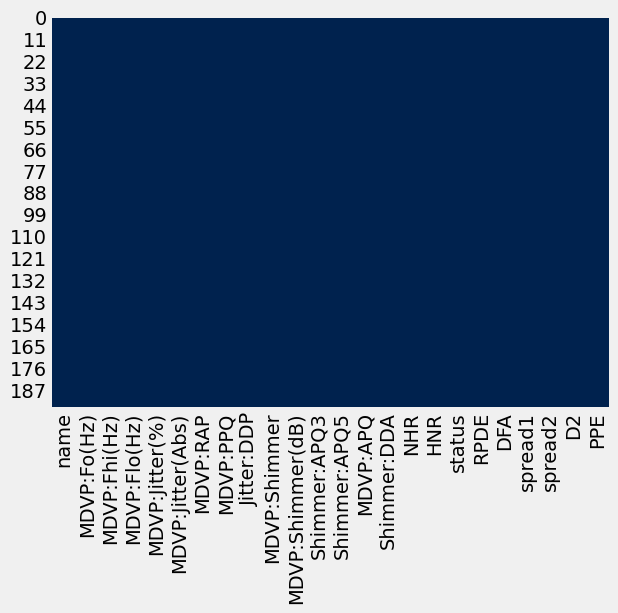

In [ ]:
sns.heatmap(df.isnull(),cbar=False,cmap='cividis')

In [ ]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (195, 24)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
name,object,0,0.0,0,195,195,NaN,NaN,NaN,NaN,phon_R01_S01_1,phon_R01_S01_2,phon_R01_S01_3
MDVP:Fo(Hz),float64,0,0.0,0,195,195,88.333,260.105,154.228641,41.390065,119.992,122.4,116.682
MDVP:Fhi(Hz),float64,0,0.0,0,195,195,102.145,592.03,197.104918,91.491548,157.302,148.65,131.111
MDVP:Flo(Hz),float64,0,0.0,0,195,195,65.476,239.17,116.324631,43.521413,74.997,113.819,111.555
MDVP:Jitter(%),float64,0,0.0,0,173,195,0.00168,0.03316,0.00622,0.004848,0.00784,0.00968,0.0105
MDVP:Jitter(Abs),float64,0,0.0,0,19,195,0.000007,0.00026,0.000044,0.000035,0.00007,0.00008,0.00009
MDVP:RAP,float64,0,0.0,0,155,195,0.00068,0.02144,0.003306,0.002968,0.0037,0.00465,0.00544
MDVP:PPQ,float64,0,0.0,0,165,195,0.00092,0.01958,0.003446,0.002759,0.00554,0.00696,0.00781
Jitter:DDP,float64,0,0.0,0,180,195,0.00204,0.06433,0.00992,0.008903,0.01109,0.01394,0.01633
MDVP:Shimmer,float64,0,0.0,0,188,195,0.00954,0.11908,0.029709,0.018857,0.04374,0.06134,0.05233


In [ ]:

for col in df.columns:
  print(f'unique({col}) = {len(df[col].unique())}')

unique(name) = 195
unique(MDVP:Fo(Hz)) = 195
unique(MDVP:Fhi(Hz)) = 195
unique(MDVP:Flo(Hz)) = 195
unique(MDVP:Jitter(%)) = 173
unique(MDVP:Jitter(Abs)) = 19
unique(MDVP:RAP) = 155
unique(MDVP:PPQ) = 165
unique(Jitter:DDP) = 180
unique(MDVP:Shimmer) = 188
unique(MDVP:Shimmer(dB)) = 149
unique(Shimmer:APQ3) = 184
unique(Shimmer:APQ5) = 189
unique(MDVP:APQ) = 189
unique(Shimmer:DDA) = 189
unique(NHR) = 185
unique(HNR) = 195
unique(status) = 2
unique(RPDE) = 195
unique(DFA) = 195
unique(spread1) = 195
unique(spread2) = 194
unique(D2) = 195
unique(PPE) = 195


In [ ]:
# Classify columns: categorical columns and numerical columns
cat_cols = [col for col in df.columns if df[col].dtype=='object']
num_cols = [col for col in df.columns if df[col].dtype!='object']

In [ ]:
cat_cols
num_cols

['MDVP:Fo(Hz)',
 'MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'MDVP:PPQ',
 'Jitter:DDP',
 'MDVP:Shimmer',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'MDVP:APQ',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'status',
 'RPDE',
 'DFA',
 'spread1',
 'spread2',
 'D2',
 'PPE']

In [ ]:
#EDA
# Target = 'status'
df['status'].unique()

array([1, 0])

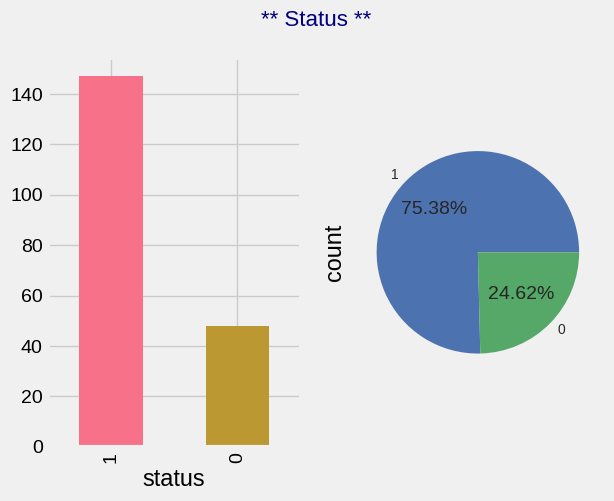

In [ ]:
fig, ax = plt.subplots(1, 2)
fig.suptitle('** ' + 'Status' + ' **', fontsize=16, color='navy')
plt.style.use('seaborn-v0_8')
plt.subplot(1,2,1)
df['status'].value_counts().plot(kind='bar',color=sns.color_palette("husl"))
plt.subplot(1,2,2)
df['status'].value_counts().plot(kind='pie',autopct="%.2f%%")
plt.show()

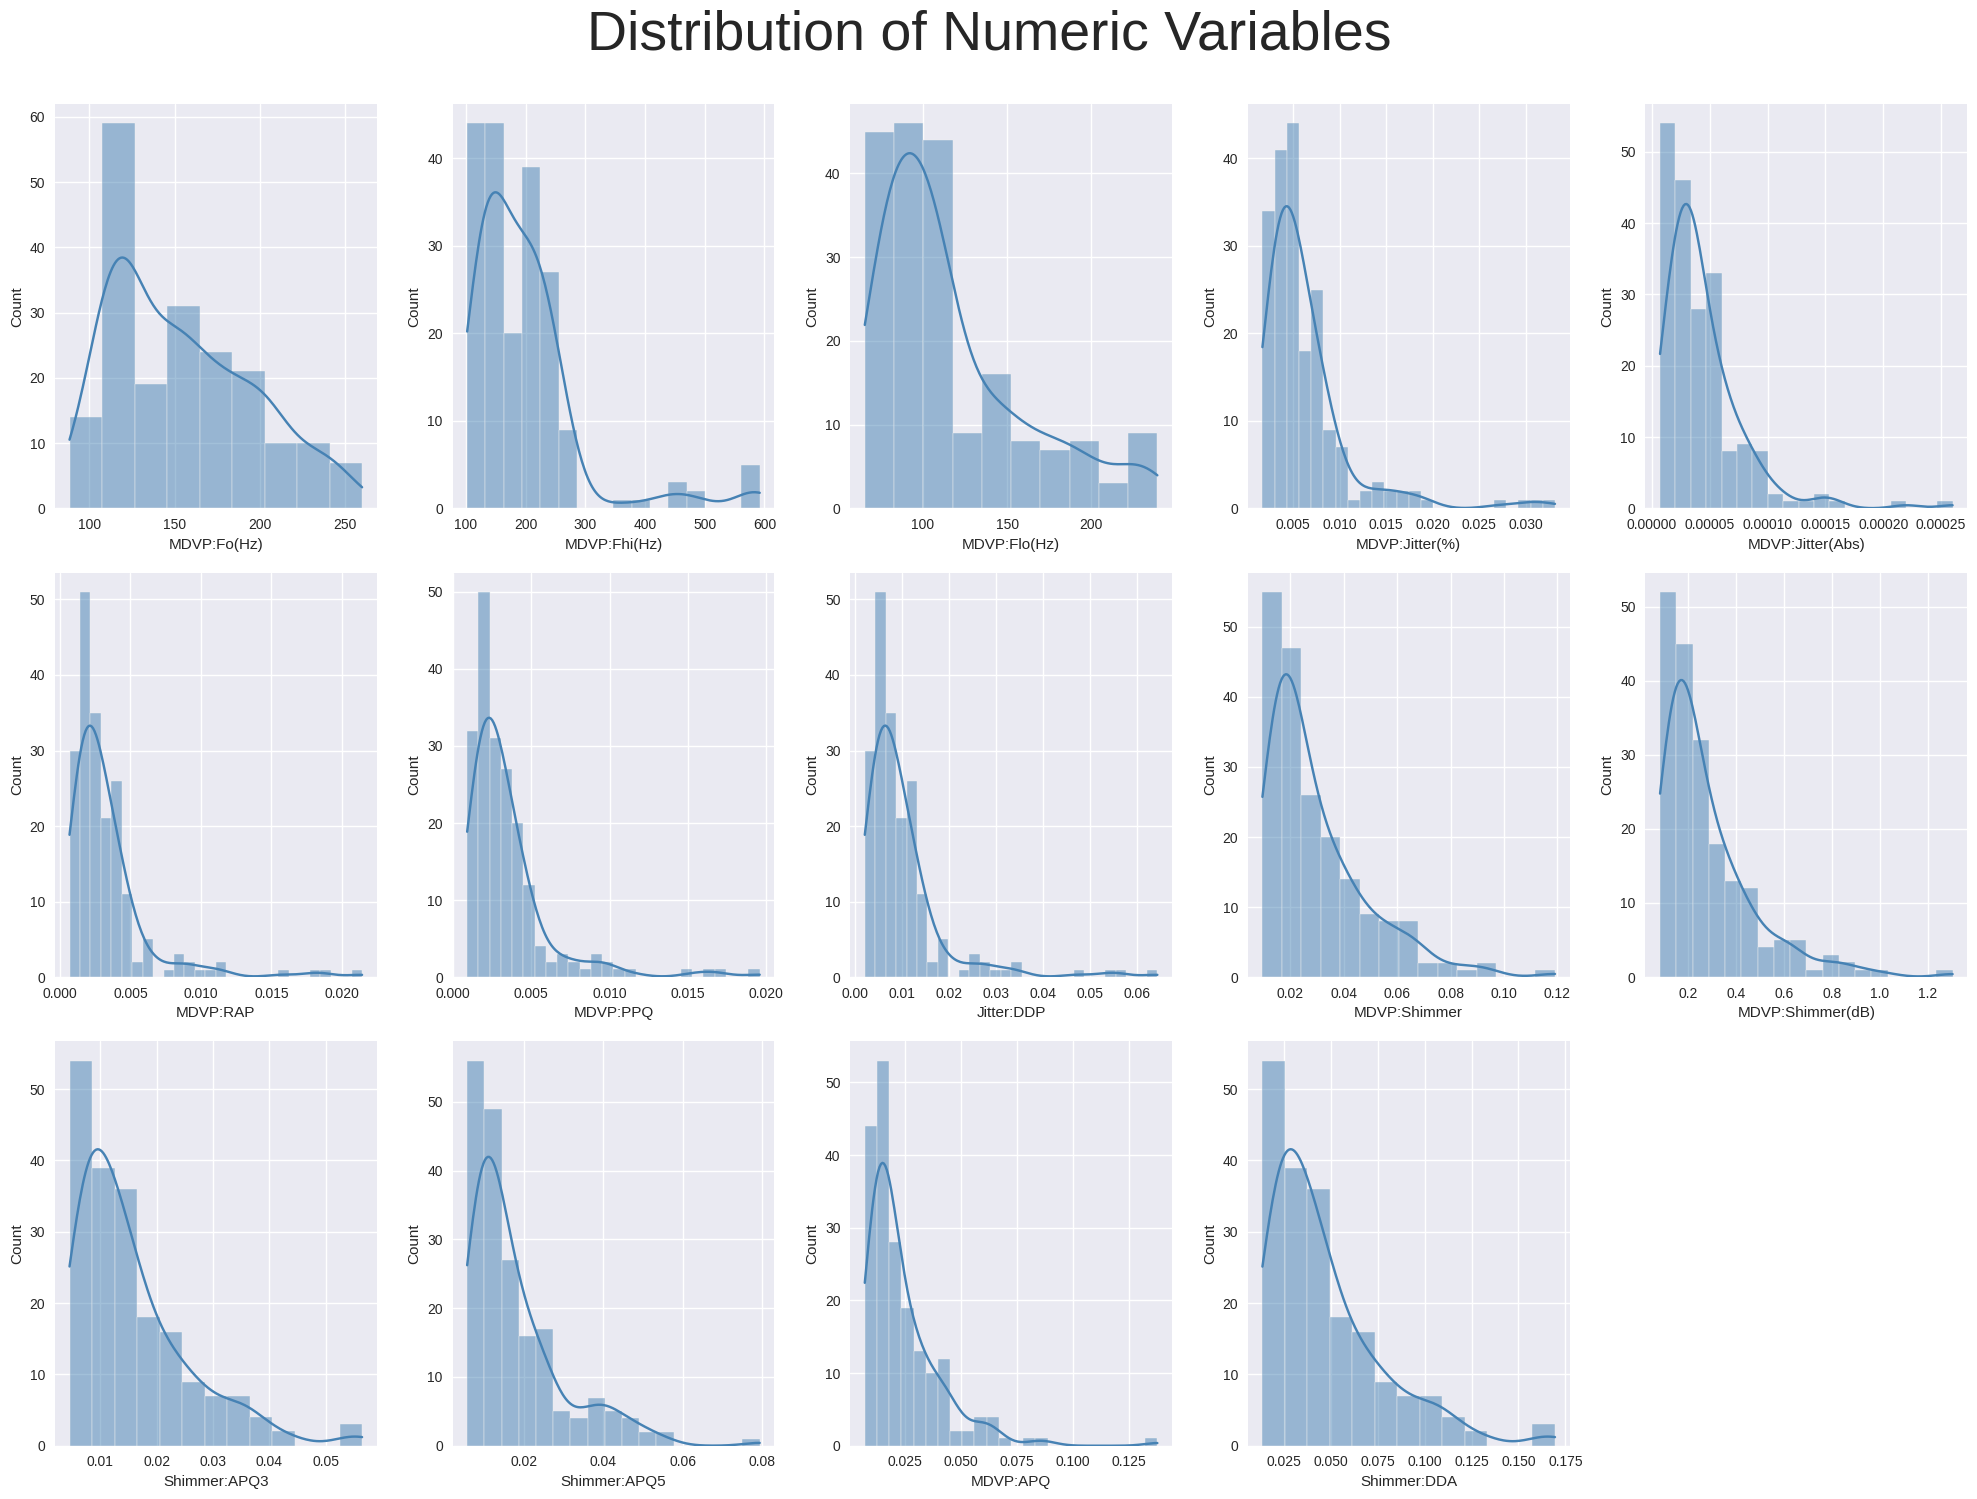

In [ ]:
# Distribution of numeric variables
plt.figure(figsize=(20, 15))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.histplot(df[column], kde=True, color='steelblue')
        plt.xlabel(column)

    plotnumber += 1

plt.suptitle('Distribution of Numeric Variables', fontsize=40, y=1)
plt.tight_layout()
plt.show()

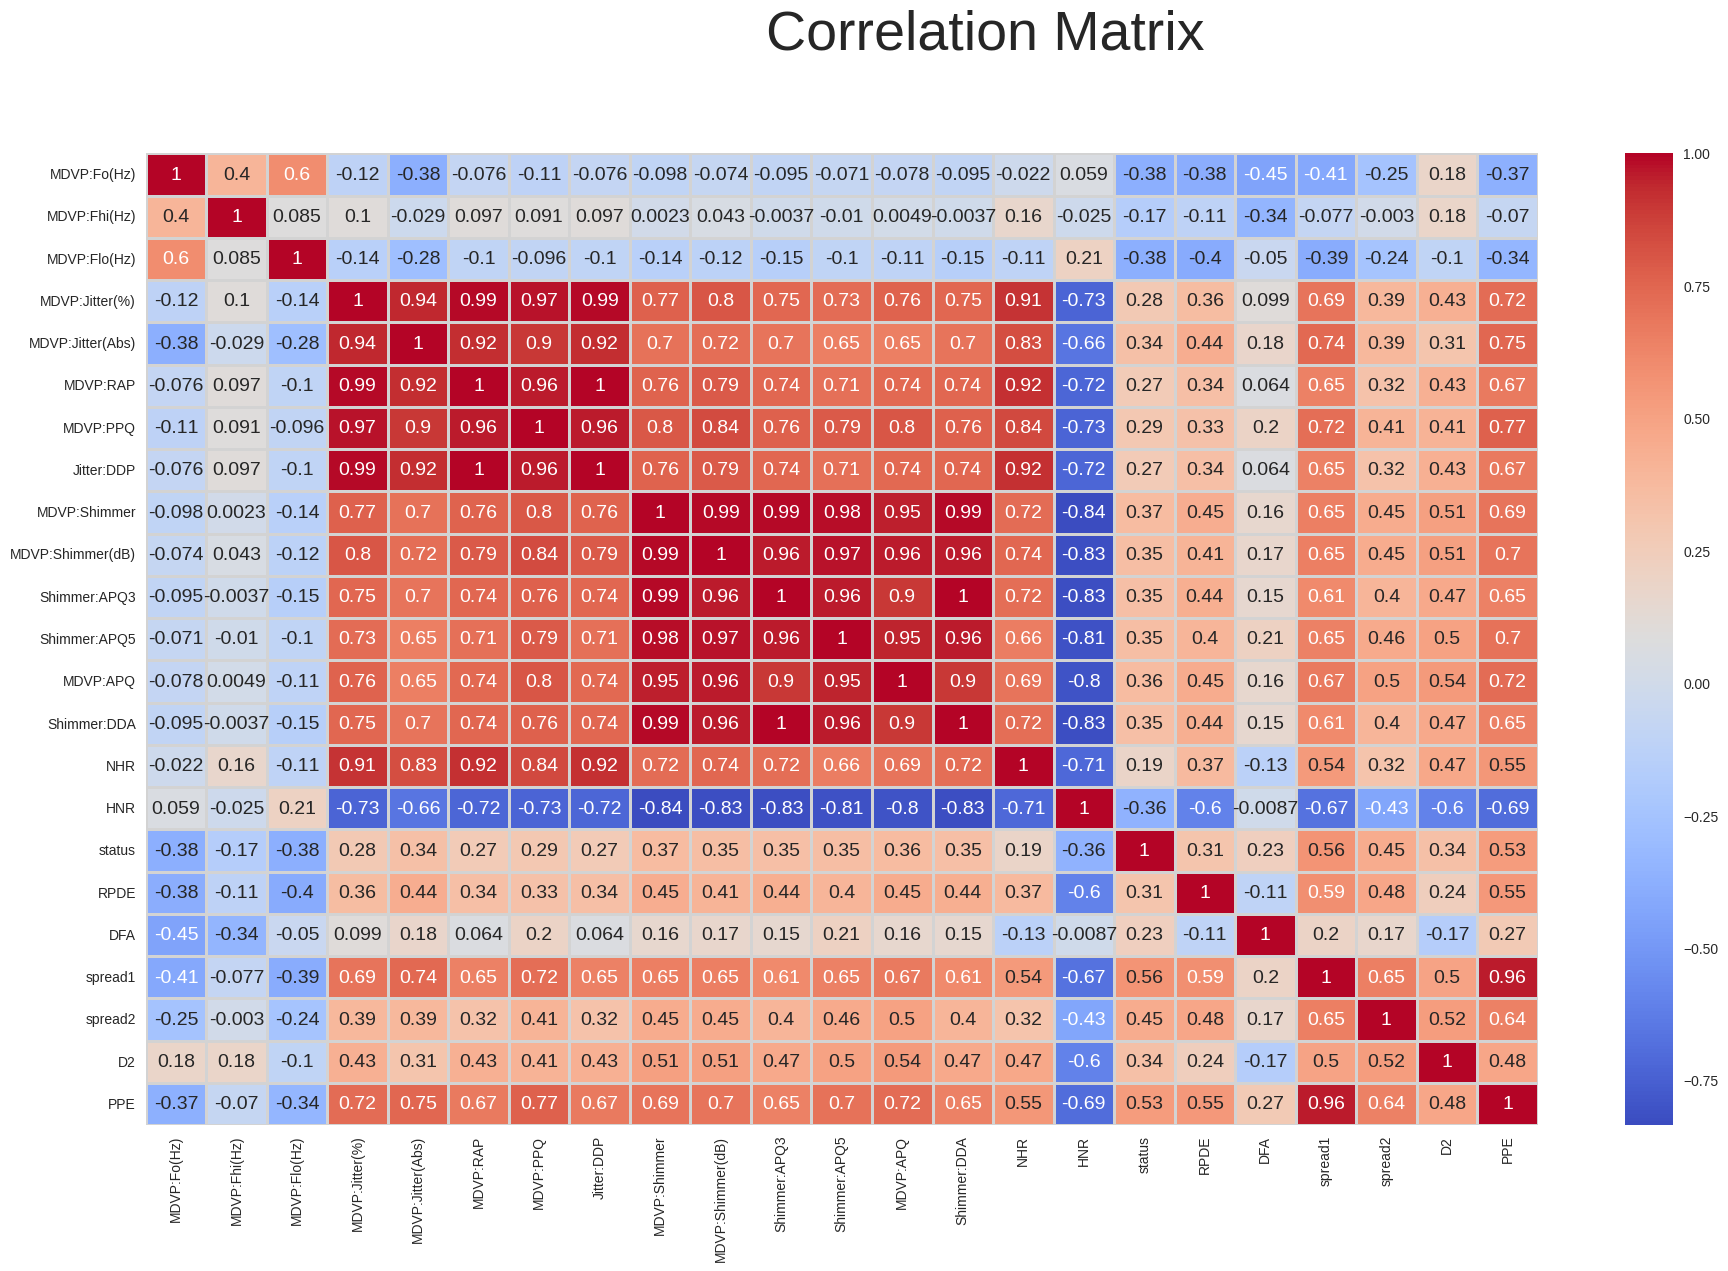

In [ ]:
# Correlation matrix of numeric columns
num_df = df[num_cols]

plt.figure(figsize=(20, 12))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', linewidths=2, linecolor='lightgrey')
plt.suptitle('Correlation Matrix', fontsize=40, y=1)
plt.show()

In [ ]:

# Let's exclude the columns that have high correlation
columns_to_drop = ['MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
                   'NHR', 'MDVP:APQ', 'Shimmer:DDA', 'PPE', 'MDVP:Jitter(Abs)',
                   'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP']
df.drop(columns=[
    col for col in columns_to_drop if col in df.columns],
        inplace=True)

In [ ]:
num_cols = [col for col in df.columns if df[col].dtype!='object']

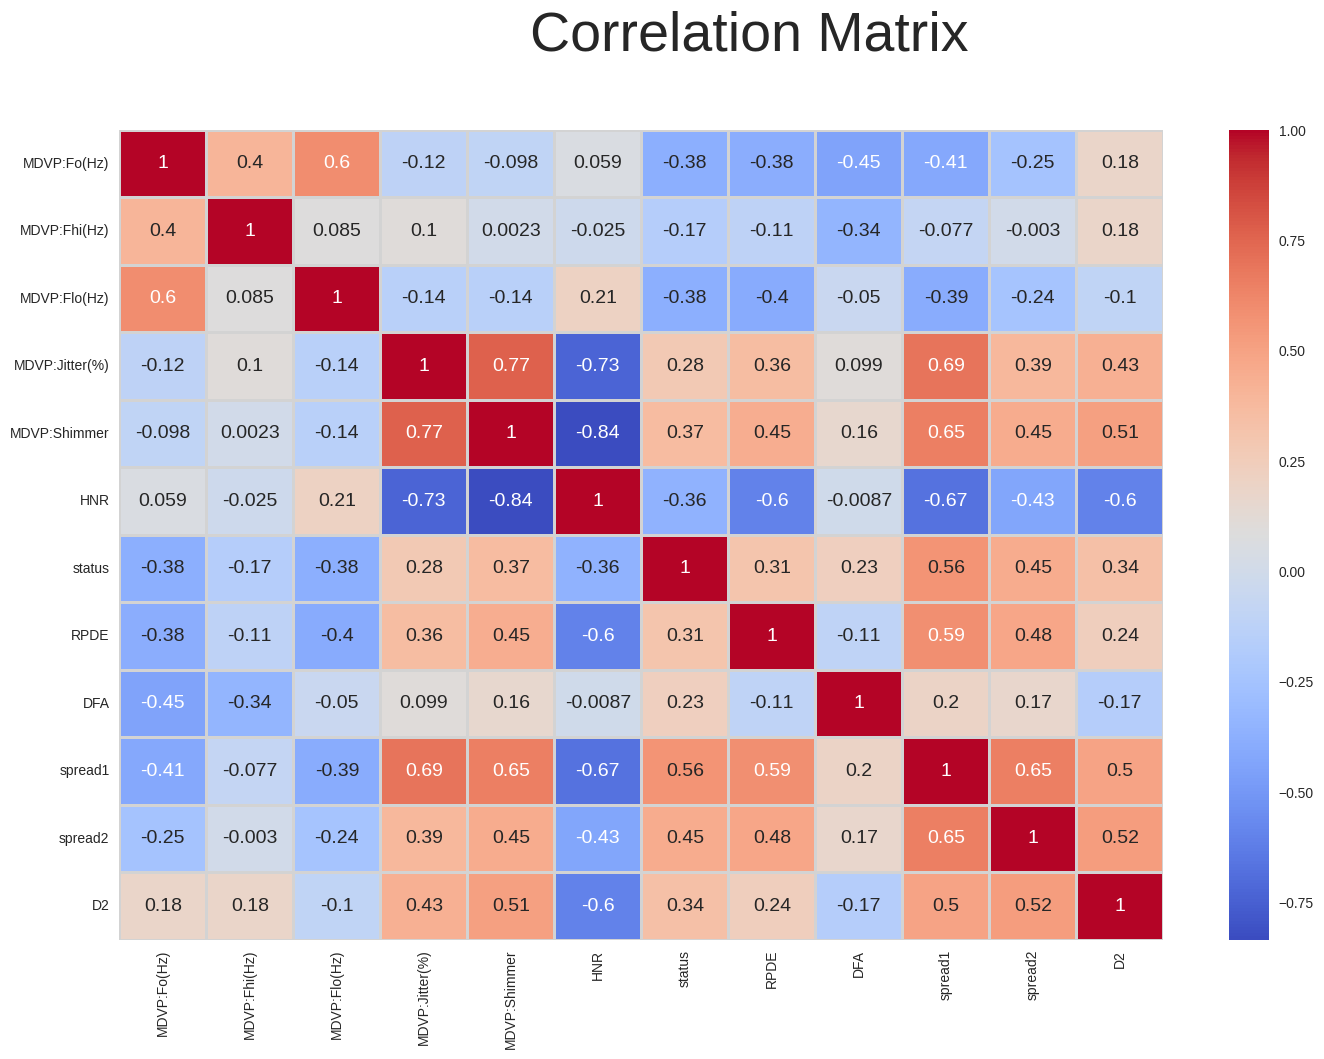

In [ ]:
# Correlation matrix of numeric columns
num_df = df[num_cols]

plt.figure(figsize=(15, 10))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', linewidths=2, linecolor='lightgrey')
plt.suptitle('Correlation Matrix', fontsize=40, y=1)
plt.show()

In [ ]:
cols = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Shimmer', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2',
       'D2']

In [ ]:
for i in cols:

    if i == 'MDVP:Fo(Hz)':
        fig = px.violin(df, y='MDVP:Fo(Hz)', x="status", color="status",
                box=True, points='all', hover_data=df.columns)
        fig.show()
    else:
        fig = px.violin(df, y=i, x="status", color="status",
                box=True, points='all', hover_data=df.columns)
        fig.show()


In [ ]:
fig = px.scatter(df, x='MDVP:Fo(Hz)', y='HNR', color="status")
fig.update_layout(width=800, height=600)
fig.show()

In [ ]:
fig = px.scatter(df, x='spread1', y='spread2', color="status")
fig.update_layout(width=800, height=600)
fig.show()

In [ ]:
fig = px.scatter(df, x='RPDE', y='DFA', color="status")
fig.update_layout(width=800, height=600)
fig.show()

In [ ]:
# Check the variance inflation factor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add constant term
df_vif = df.copy()
df_vif['const'] = 1

# Select the columns for which VIF needs to be calculated
X = df_vif[num_cols + ['const']]

# Calculate VIF
vif_info = pd.DataFrame()
vif_info['Column'] = X.columns
vif_info['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_info = vif_info.sort_values('VIF', ascending=False)

# Show results
vif_info

,Column,VIF
12,const,1672.575225
5,HNR,6.257077
9,spread1,4.608716
4,MDVP:Shimmer,4.449965
3,MDVP:Jitter(%),3.613030
0,MDVP:Fo(Hz),3.359199
7,RPDE,3.232691
11,D2,2.717530
10,spread2,2.417264
8,DFA,1.997522


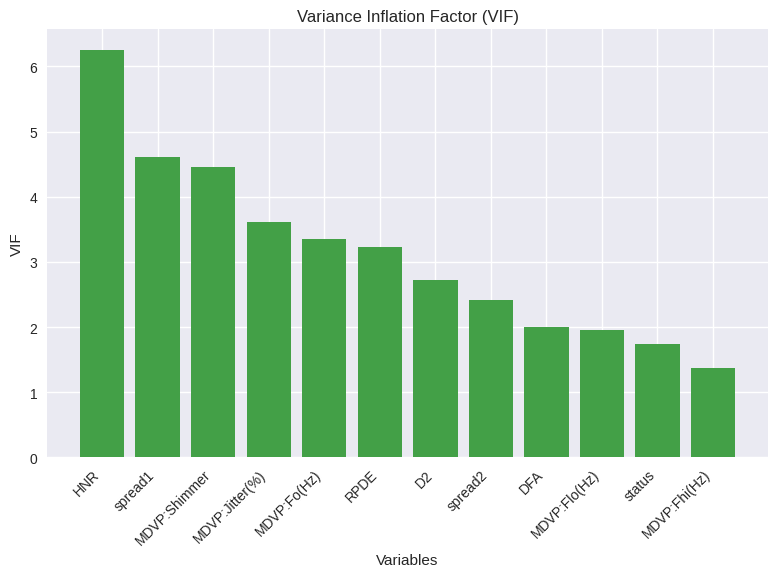

In [ ]:
# Result visualization
# Remove const columns
vif_info_filtered = vif_info[vif_info['Column'] != 'const']
vif_info_sorted = vif_info_filtered.sort_values('VIF', ascending=False)

plt.figure(figsize=(8, 6))
plt.bar(vif_info_sorted['Column'], vif_info_sorted['VIF'], color='#43A047')
plt.xlabel('Variables')
plt.ylabel('VIF')
plt.title('Variance Inflation Factor (VIF)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Feature Encoding
# Check the number of categories in the category column
for col in cat_cols:
    print(f"{col} has {df[col].nunique()} categories\n")

name has 195 categories



In [ ]:
# Feature encoding (label encoding)
# Convert categories to numeric values using category labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Modelling
# Prepare training data for the machine learning model
# Define independent variables
ind_col = [col for col in df.columns if col!='status']
# Define dependent variable
dep_col = 'status'

X = df[ind_col]
y = df[dep_col]

In [ ]:
from sklearn.model_selection import train_test_split

# Divide the data set into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Features normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Training Accuracy (KNN): 0.955

Evaluation on Test Data:
Accuracy      : 0.9744
Precision     : 0.9848
Recall        : 0.9286
F1 Score      : 0.9538

Confusion Matrix:
 [[ 6  1]
 [ 0 32]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.97      1.00      0.98        32

    accuracy                           0.97        39
   macro avg       0.98      0.93      0.95        39
weighted avg       0.98      0.97      0.97        39



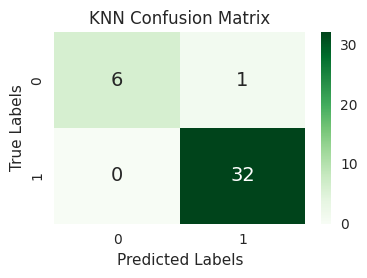

In [ ]:
# K-Nearest Neighbors (KNN)

# Import necessary modules
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Model Initialization and Training
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Step 2: Make Predictions on Test Set
test_predictions = knn_model.predict(X_test)
train_predictions = knn_model.predict(X_train)

# Step 3: Evaluate on Training Data
train_accuracy = accuracy_score(y_train, train_predictions)
print("Training Accuracy (KNN): {:.3f}".format(train_accuracy))

# Step 4: Compute Evaluation Metrics on Test Data
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions, average='macro')
test_recall = recall_score(y_test, test_predictions, average='macro')
test_f1 = f1_score(y_test, test_predictions, average='macro')
conf_matrix = confusion_matrix(y_test, test_predictions)

# Step 5: Display Evaluation Results
print("\nEvaluation on Test Data:")
print("Accuracy      :", round(test_accuracy, 4))
print("Precision     :", round(test_precision, 4))
print("Recall        :", round(test_recall, 4))
print("F1 Score      :", round(test_f1, 4))
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, test_predictions))

# Step 6: Confusion Matrix Heatmap
sns.set_style("whitegrid")
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, cmap='Greens', fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()


Training Accuracy (Logistic Regression): 0.8526

Logistic Regression Test Results:
Accuracy : 0.8974
Precision: 0.9444
Recall   : 0.7143
F1 Score : 0.9538

Confusion Matrix:
 [[ 3  4]
 [ 0 32]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.89      1.00      0.94        32

    accuracy                           0.90        39
   macro avg       0.94      0.71      0.77        39
weighted avg       0.91      0.90      0.88        39



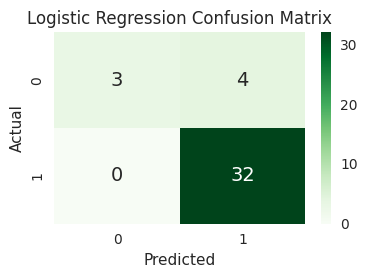

In [ ]:
# Logistic Regression

# Required imports
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Initialize and Train Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Step 2: Make Predictions
test_output = lr_model.predict(X_test)
train_output = lr_model.predict(X_train)

# Step 3: Training Accuracy
train_acc = accuracy_score(y_train, train_output)
print("Training Accuracy (Logistic Regression): {:.4f}\n".format(train_acc))

# Step 4: Performance on Test Set
test_acc = accuracy_score(y_test, test_output)
test_prec = precision_score(y_test, test_output, average='macro')
test_rec = recall_score(y_test, test_output, average='macro')
testt_f1 = f1_score(y_test, test_output, average='macro')
conf_mat = confusion_matrix(y_test, test_output)

# Step 5: Print Evaluation Metrics
print("Logistic Regression Test Results:")
print("Accuracy :", round(test_acc, 4))
print("Precision:", round(test_prec, 4))
print("Recall   :", round(test_rec, 4))
print("F1 Score :", round(test_f1, 4))
print("\nConfusion Matrix:\n", conf_mat)
print("\nClassification Report:\n", classification_report(y_test, test_output))

# Step 6: Visualize Confusion Matrix
plt.figure(figsize=(4, 3))
sns.set_style("whitegrid")
sns.heatmap(conf_mat, annot=True, cmap='Greens', fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Training Accuracy (Decision Tree): 1.0000

Decision Tree Evaluation on Test Set:
Accuracy : 0.9487
Precision: 0.9129
Recall   : 0.9129
F1 Score : 0.9129

Confusion Matrix:
 [[ 6  1]
 [ 1 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.97      0.97      0.97        32

    accuracy                           0.95        39
   macro avg       0.91      0.91      0.91        39
weighted avg       0.95      0.95      0.95        39



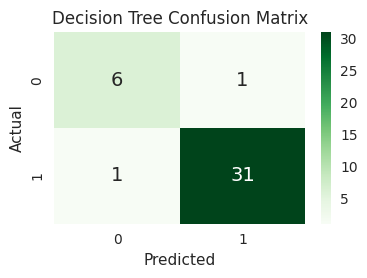

In [ ]:
# Decision Tree

# Import required libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Model Initialization and Training
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Step 2: Generate Predictions
train_preds = tree_model.predict(X_train)
test_preds = tree_model.predict(X_test)

# Step 3: Evaluate Training Performance
train_tree_acc = accuracy_score(y_train, train_preds)
print("Training Accuracy (Decision Tree): {:.4f}\n".format(train_tree_acc))

# Step 4: Evaluate Test Performance
test_tree_acc = accuracy_score(y_test, test_preds)
test_tree_prec = precision_score(y_test, test_preds, average='macro')
test_tree_rec = recall_score(y_test, test_preds, average='macro')
test_tree_f1 = f1_score(y_test, test_preds, average='macro')
tree_cm = confusion_matrix(y_test, test_preds)

# Step 5: Print Evaluation Metrics
print("Decision Tree Evaluation on Test Set:")
print("Accuracy :", round(test_tree_acc, 4))
print("Precision:", round(test_tree_prec, 4))
print("Recall   :", round(test_tree_rec, 4))
print("F1 Score :", round(test_tree_f1, 4))
print("\nConfusion Matrix:\n", tree_cm)
print("\nClassification Report:\n", classification_report(y_test, test_preds))

# Step 6: Plot Confusion Matrix
plt.figure(figsize=(4, 3))
sns.set_style("whitegrid")
sns.heatmap(tree_cm, annot=True, cmap='Greens', fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Training Accuracy (Random Forest): 1.0000

Random Forest Test Performance:
Accuracy : 0.9231
Precision: 0.8864
Recall   : 0.8415
F1 Score : 0.8615

Confusion Matrix:
 [[ 5  2]
 [ 1 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.94      0.97      0.95        32

    accuracy                           0.92        39
   macro avg       0.89      0.84      0.86        39
weighted avg       0.92      0.92      0.92        39



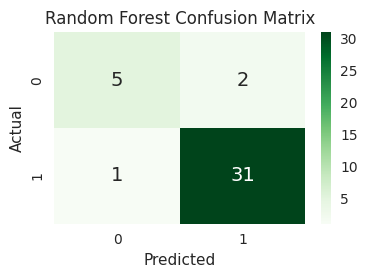

In [ ]:
# Random Forest

# Import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Initialize and Train the Random Forest Classifier
forest_model = RandomForestClassifier()
forest_model.fit(X_train, y_train)

# Step 2: Generate Predictions
rf_train_preds = forest_model.predict(X_train)
rf_test_preds = forest_model.predict(X_test)

# Step 3: Training Accuracy
rf_train_accuracy = accuracy_score(y_train, rf_train_preds)
print("Training Accuracy (Random Forest): {:.4f}\n".format(rf_train_accuracy))

# Step 4: Evaluate on Test Data
rf_test_accuracy = accuracy_score(y_test, rf_test_preds)
rf_test_precision = precision_score(y_test, rf_test_preds, average='macro')
rf_test_recall = recall_score(y_test, rf_test_preds, average='macro')
rf_test_f1 = f1_score(y_test, rf_test_preds, average='macro')
rf_conf_matrix = confusion_matrix(y_test, rf_test_preds)

# Step 5: Display Evaluation Metrics
print("Random Forest Test Performance:")
print("Accuracy :", round(rf_test_accuracy, 4))
print("Precision:", round(rf_test_precision, 4))
print("Recall   :", round(rf_test_recall, 4))
print("F1 Score :", round(rf_test_f1, 4))
print("\nConfusion Matrix:\n", rf_conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, rf_test_preds))

# Step 6: Visualize Confusion Matrix
plt.figure(figsize=(4, 3))
sns.set_style("whitegrid")
sns.heatmap(rf_conf_matrix, annot=True, cmap='Greens', fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Training Accuracy (AdaBoost): 1.0000

AdaBoost Evaluation on Test Set:
Accuracy : 0.9744
Precision: 0.9848
Recall   : 0.9286
F1 Score : 0.9538

Confusion Matrix:
 [[ 6  1]
 [ 0 32]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.97      1.00      0.98        32

    accuracy                           0.97        39
   macro avg       0.98      0.93      0.95        39
weighted avg       0.98      0.97      0.97        39



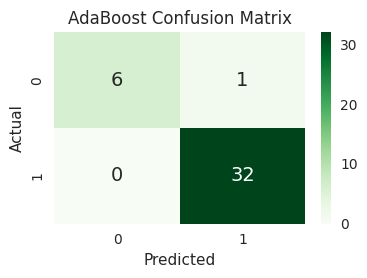

In [ ]:
# Adaptive Boosting (AdaBoost)

# Import necessary libraries
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Initialize and Train AdaBoost Model
boost_model = AdaBoostClassifier()
boost_model.fit(X_train, y_train)

# Step 2: Predict on Training and Test Sets
boost_train_preds = boost_model.predict(X_train)
boost_test_preds = boost_model.predict(X_test)

# Step 3: Evaluate Training Accuracy
boost_train_acc = accuracy_score(y_train, boost_train_preds)
print("Training Accuracy (AdaBoost): {:.4f}\n".format(boost_train_acc))

# Step 4: Compute Metrics on Test Data
boost_test_acc = accuracy_score(y_test, boost_test_preds)
boost_test_prec = precision_score(y_test, boost_test_preds, average='macro')
boost_test_rec = recall_score(y_test, boost_test_preds, average='macro')
boost_test_f1 = f1_score(y_test, boost_test_preds, average='macro')
boost_cm = confusion_matrix(y_test, boost_test_preds)

# Step 5: Display Evaluation Results
print("AdaBoost Evaluation on Test Set:")
print("Accuracy :", round(boost_test_acc, 4))
print("Precision:", round(boost_test_prec, 4))
print("Recall   :", round(boost_test_rec, 4))
print("F1 Score :", round(boost_test_f1, 4))
print("\nConfusion Matrix:\n", boost_cm)
print("\nClassification Report:\n", classification_report(y_test, boost_test_preds))

# Step 6: Visualize the Confusion Matrix
plt.figure(figsize=(4, 3))
sns.set_style("whitegrid")
sns.heatmap(boost_cm, annot=True, cmap='Greens', fmt='d')
plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Training Accuracy (XGBoost): 1.0000

XGBoost Performance on Test Set:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Confusion Matrix:
 [[ 7  0]
 [ 0 32]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        32

    accuracy                           1.00        39
   macro avg       1.00      1.00      1.00        39
weighted avg       1.00      1.00      1.00        39



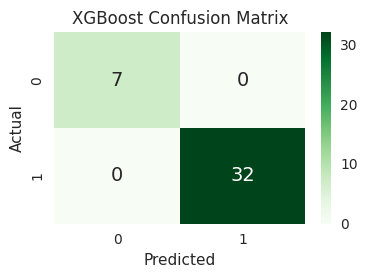

In [ ]:
# Import required libraries
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Initialize and Train the XGBoost Model
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

# Step 2: Predict on Training and Test Data
xgb_train_preds = xgb_model.predict(X_train)
xgb_test_preds = xgb_model.predict(X_test)

# Step 3: Calculate Training Accuracy
xgb_train_accuracy = accuracy_score(y_train, xgb_train_preds)
print("Training Accuracy (XGBoost): {:.4f}\n".format(xgb_train_accuracy))

# Step 4: Evaluate the Model on Test Data
xgb_test_accuracy = accuracy_score(y_test, xgb_test_preds)
xgb_test_precision = precision_score(y_test, xgb_test_preds, average='macro')
xgb_test_recall = recall_score(y_test, xgb_test_preds, average='macro')
xgb_test_f1 = f1_score(y_test, xgb_test_preds, average='macro')
xgb_conf_matrix = confusion_matrix(y_test, xgb_test_preds)



# Step 5: Display Evaluation Results
print("XGBoost Performance on Test Set:")
print("Accuracy :", round(xgb_test_accuracy, 4))
print("Precision:", round(xgb_test_precision, 4))
print("Recall   :", round(xgb_test_recall, 4))
print("F1 Score :", round(xgb_test_f1, 4))
print("\nConfusion Matrix:\n", xgb_conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, xgb_test_preds))

# Step 6: Visualize Confusion Matrix with a Heatmap
plt.figure(figsize=(4, 3))
sns.set_style("whitegrid")
sns.heatmap(xgb_conf_matrix, annot=True, cmap='Greens', fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Model Comparison

In [ ]:
# Accuracy scores of different models

import pandas as pd

# Step 1: Create DataFrame for Model Accuracies
model_accuracy_data = {
    'Model': [
        'KNN', 'Logistic Regression',
        'Decision Tree', 'Random Forest',  'AdaBoost',
         'XGBoost'],
    'Accuracy': [
        test_accuracy, test_acc,
        test_tree_acc, rf_test_accuracy,  boost_test_acc,
        xgb_test_accuracy ]
}

# Step 2: Convert the dictionary to a pandas DataFrame
accuracy_df = pd.DataFrame(model_accuracy_data)

# Step 3: Sort the models by their accuracy in descending order
sorted_accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

# Step 4: Display the sorted accuracy DataFrame
sorted_accuracy_df


import plotly.express as px

# Step 1: Create a bar plot for model accuracy comparison
accuracy_plot = px.bar(
    data_frame=sorted_accuracy_df,  # Use the sorted accuracy DataFrame
    x='Model',
    y='Accuracy',
    color='Accuracy',  # Color bars based on accuracy values
    title='Model Accuracy Comparison',
    text='Accuracy'  # Display accuracy scores on the bars
)

# Step 2: Update plot layout for better presentation
accuracy_plot.update_layout(
    width=800,  # Set the width of the plot
    height=600,  # Set the height of the plot
    xaxis_title='Model',  # Label for the x-axis
    yaxis_title='Accuracy',  # Label for the y-axis
    template='plotly_dark'  # Optional: Set a plot theme (you can change it if you like)
)

# Step 3: Show the plot
accuracy_plot.show()


In [ ]:
# Precision scores of different models

import pandas as pd

# Step 1: Create DataFrame for Model Precision Scores
model_precision_data = {
    'Model': [
        'KNN', 'Logistic Regression',
        'Decision Tree', 'Random Forest',  'AdaBoost',
         'XGBoost'],
    'Precision': [
        test_precision, test_prec, test_tree_prec, rf_test_precision,boost_test_prec,
         xgb_test_precision]
}

# Step 2: Convert the dictionary to a pandas DataFrame
precision_df = pd.DataFrame(model_precision_data)

# Step 3: Sort the models by their precision score in descending order
sorted_precision_df = precision_df.sort_values(by='Precision', ascending=False)

# Step 4: Display the sorted precision DataFrame
sorted_precision_df



import plotly.express as px

# Step 1: Create a bar plot for model precision comparison
precision_plot = px.bar(
    data_frame=sorted_precision_df,  # Use the sorted precision DataFrame
    x='Model',
    y='Precision',  # Changed to 'Precision' based on the updated DataFrame
    color='Precision',  # Color bars based on precision values
    title='Model Precision Comparison',
    text='Precision'  # Display precision scores on the bars
)

# Step 2: Update plot layout for better presentation
precision_plot.update_layout(
    width=800,  # Set the width of the plot
    height=600,  # Set the height of the plot
    xaxis_title='Model',  # Label for the x-axis
    yaxis_title='Precision',  # Label for the y-axis
    template='plotly_dark'  # Optional: Set a plot theme (you can change it if you like)
)

# Step 3: Show the plot
precision_plot.show()


In [ ]:
# Recall scores of different models

import pandas as pd

# Step 1: Create DataFrame for Model Recall Scores
model_recall_data = {
    'Model': [
        'KNN', 'Logistic Regression',
        'Decision Tree', 'Random Forest', 'AdaBoost',
        'XGBoost'],
    'Recall': [
        test_recall, test_rec, test_tree_rec, rf_test_recall, boost_test_rec,
        xgb_test_recall]
}

# Step 2: Convert the dictionary to a pandas DataFrame
recall_df = pd.DataFrame(model_recall_data)

# Step 3: Sort the models by their recall score in descending order
sorted_recall_df = recall_df.sort_values(by='Recall', ascending=False)

# Step 4: Display the sorted recall DataFrame
sorted_recall_df

import plotly.express as px

# Step 1: Create a bar plot for model recall comparison
recall_plot = px.bar(
    data_frame=sorted_recall_df,  # Use the sorted recall DataFrame
    x='Model',
    y='Recall',  # Changed to 'Recall' for this plot
    color='Recall',  # Color bars based on recall values
    title='Model Recall Comparison',
    text='Recall'  # Display recall scores on the bars
)

# Step 2: Update plot layout for better presentation
recall_plot.update_layout(
    width=800,  # Set the width of the plot
    height=600,  # Set the height of the plot
    xaxis_title='Model',  # Label for the x-axis
    yaxis_title='Recall',  # Label for the y-axis
    template='plotly_dark'  # Optional: Set a plot theme (you can change it if you like)
)

# Step 3: Show the plot
recall_plot.show()


In [ ]:
# F1 scores of different models

import pandas as pd

# Step 1: Create DataFrame for Model F1 Scores
model_f1_data = {
    'Model': [
        'KNN', 'Logistic Regression',
        'Decision Tree', 'Random Forest', 'AdaBoost',
        'XGBoost'],
    'F1 Score': [
        test_f1, testt_f1, test_tree_f1, rf_test_f1, boost_test_f1,
        xgb_test_f1]
}

# Step 2: Convert the dictionary to a pandas DataFrame
f1_df = pd.DataFrame(model_f1_data)

# Step 3: Sort the models by their F1 score in descending order
sorted_f1_df = f1_df.sort_values(by='F1 Score', ascending=False)

# Step 4: Display the sorted F1 score DataFrame
sorted_f1_df

import plotly.express as px

# Step 1: Create a bar plot for model F1 score comparison
f1_plot = px.bar(
    data_frame=sorted_f1_df,  # Use the sorted F1 DataFrame
    x='Model',
    y='F1 Score',  # Changed to 'F1 Score' for this plot
    color='F1 Score',  # Color bars based on F1 score values
    title='Model F1 Score Comparison',
    text='F1 Score'  # Display F1 scores on the bars
)

# Step 2: Update plot layout for better presentation
f1_plot.update_layout(
    width=800,  # Set the width of the plot
    height=600,  # Set the height of the plot
    xaxis_title='Model',  # Label for the x-axis
    yaxis_title='F1 Score',  # Label for the y-axis
    template='plotly_dark'  # Optional: Set a plot theme
)

# Step 3: Show the plot
f1_plot.show()
